# Final Model Evaluation

Fits two Cox PH models (with and without PGS), reports their concordance indices with 95% CIs, and plots a forest-style comparison against the external **PANGEA** benchmark (MGUS patient at 1st visit, no BM).

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index, k_fold_cross_validation
from core.artifacts import CoxBootstrapBundle

## Load data

In [2]:
for p in ['cleaned_data/mm_nopgs.csv', 'cleaned_data/mm_pgs_bin.csv', 'cleaned_data/feature_stats.json']:
    assert Path(p).exists(), f'{p} not found — run clean_data.ipynb first.'

df_nopgs  = pd.read_csv('cleaned_data/mm_nopgs.csv',     index_col='ID')
df_pgsbin = pd.read_csv('cleaned_data/mm_pgs_bin.csv',   index_col='ID')

with open('cleaned_data/feature_stats.json') as f:
    feature_stats = json.load(f)

print(f'No-PGS dataset:  {len(df_nopgs)} rows,  columns: {list(df_nopgs.columns)}')
print(f'PGS-bin dataset: {len(df_pgsbin)} rows, columns: {list(df_pgsbin.columns)}')
print(f'Feature stats loaded for: {list(feature_stats.keys())}')

No-PGS dataset:  2000 rows,  columns: ['age', 'm_spike', 'sflc_ratio', 'creatinine', 'time_years', 'status']
PGS-bin dataset: 2000 rows, columns: ['age', 'm_spike', 'sflc_ratio', 'creatinine', 'time_years', 'status', 'pgs_bin']
Feature stats loaded for: ['age', 'm_spike', 'sflc_ratio', 'creatinine', 'pgs_score']


## Fit Cox PH models

In [3]:
def c_index(df):
    cph = CoxPHFitter()
    scores = k_fold_cross_validation(
        cph, df, duration_col='time_years', 
        event_col='status', k=5, scoring_method="concordance_index"
    )
    return np.mean(scores)

cox_nopgs = CoxPHFitter()
cox_nopgs.fit(df_nopgs, duration_col='time_years', event_col='status')
nopgs_c_index = c_index(df_nopgs)

cox_pgsbin = CoxPHFitter()
cox_pgsbin.fit(df_pgsbin, duration_col='time_years', event_col='status')
pgs_c_index = c_index(df_pgsbin)

print(f'C-index  (no PGS): {nopgs_c_index:.4f}')
print(f'C-index (PGS bin): {pgs_c_index:.4f}')

C-index  (no PGS): 0.6872
C-index (PGS bin): 0.7045


## Bootstrap 95% CIs

We bootstrap to provide 95% CIs, both for reporting C-index and for rendering confidence intervals on prediction graphs.

**Important:** each bootstrap iteration fits on a resample but evaluates C-index on the **original data**. Evaluating in-sample on the bootstrap data (the naive approach) produces artificially low C-indices (~0.5) because duplicate rows get identical risk scores — tied predicted values are counted as 0.5-concordant per pair, swamping the calculation as ~37% of rows are duplicates on average.

In [4]:
def bootstrap(df, n_boot=100, seed=42):
    rng = np.random.default_rng(seed)
    c_stats = []
    models = []
    for _ in range(n_boot):
        sample = df.sample(n=len(df), replace=True, random_state=int(rng.integers(1e9)))
        cox = CoxPHFitter()
        cox.fit(sample, duration_col='time_years', event_col='status')
        risk_scores = cox.predict_partial_hazard(df)
        c = concordance_index(df['time_years'], -risk_scores, df['status'])
        c_stats.append(c)
        models.append(cox)
    return np.percentile(c_stats, [2.5, 97.5]), models

print('Bootstrapping PGS bin model...')
ci_pgsbin, pgsbin_boot_models = bootstrap(df_pgsbin)
print(f'  95% CI: {ci_pgsbin[0]:.3f}–{ci_pgsbin[1]:.3f}')

print('Bootstrapping no-PGS model...')
ci_nopgs, nopgs_boot_models = bootstrap(df_nopgs)
print(f'  95% CI: {ci_nopgs[0]:.3f}–{ci_nopgs[1]:.3f}')

Bootstrapping PGS bin model...
  95% CI: 0.699–0.713
Bootstrapping no-PGS model...
  95% CI: 0.682–0.698


## Export final models

In [5]:
def export_model(title, real_model, bootstrap_models):
    bundle = CoxBootstrapBundle(real_model, bootstrap_models, feature_stats=feature_stats)
    output_path = f'models/{title}.pkl'
    bundle.save(output_path)
    print(f"Saved {1 + len(bootstrap_models)} Cox models to {output_path}")

export_model('mm_nopgs', cox_nopgs, nopgs_boot_models)
export_model('mm_pgs_bin', cox_pgsbin, pgsbin_boot_models)

Saved 101 Cox models to models/mm_nopgs.pkl
Saved 101 Cox models to models/mm_pgs_bin.pkl


## C-index comparison — forest plot

PANGEA benchmark: MGUS patient at 1st visit, no bone marrow biopsy.  
C-statistic: **0.879 (0.586–0.938)** (externally reported).

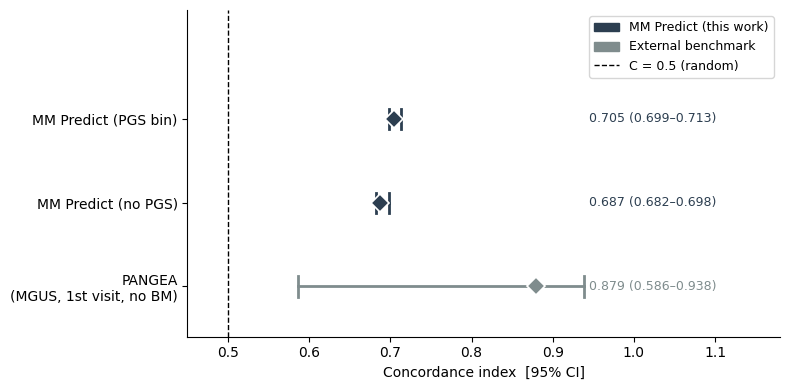

In [6]:
models = [
    {
        'label':    'PANGEA\n(MGUS, 1st visit, no BM)',
        'c':         0.879,
        'lo':        0.586,
        'hi':        0.938,
        'external':  True,
    },
    {
        'label':    'MM Predict (no PGS)',
        'c':         nopgs_c_index,
        'lo':        ci_nopgs[0],
        'hi':        ci_nopgs[1],
        'external':  False,
    },
    {
        'label':    'MM Predict (PGS bin)',
        'c':         pgs_c_index,
        'lo':        ci_pgsbin[0],
        'hi':        ci_pgsbin[1],
        'external':  False,
    },
]

OUR_COLOR = '#2c3e50'
EXT_COLOR = '#7f8c8d'

fig, ax = plt.subplots(figsize=(8, 4.0))

for i, m in enumerate(models):
    color = EXT_COLOR if m['external'] else OUR_COLOR
    lo, hi, c = m['lo'], m['hi'], m['c']

    ax.plot([lo, hi], [i, i], color=color, linewidth=2, zorder=2)
    ax.plot([lo, lo], [i - 0.12, i + 0.12], color=color, linewidth=2, zorder=2)
    ax.plot([hi, hi], [i - 0.12, i + 0.12], color=color, linewidth=2, zorder=2)
    ax.plot(c, i, 'D', color=color, markersize=9, zorder=3,
            markeredgecolor='white', markeredgewidth=1.2)

    ax.text(
        0.945, i,
        f'{c:.3f} ({lo:.3f}–{hi:.3f})',
        va='center', ha='left', fontsize=9, color=color
    )

ref_line = ax.axvline(x=0.5, color='black', linewidth=1, linestyle='--', label='C = 0.5 (random)')

ax.set_yticks(range(len(models)))
ax.set_yticklabels([m['label'] for m in models], fontsize=10)
ax.set_xlabel('Concordance index  [95% CI]', fontsize=10)
ax.set_xlim(0.45, 1.18)
ax.set_ylim(-0.6, len(models) + 0.3)
ax.spines[['top', 'right']].set_visible(False)

legend_handles = [
    mpatches.Patch(color=OUR_COLOR, label='MM Predict (this work)'),
    mpatches.Patch(color=EXT_COLOR, label='External benchmark'),
    ref_line,
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper right')

plt.savefig("img/c_indices_vs_pangea.svg")
plt.tight_layout()
plt.show()

## Summary table

In [7]:
rows = []
for m in reversed(models):
    rows.append({
        'Model':   m['label'].replace('\n', ' '),
        'C-index': round(m['c'],  3),
        'CI lower': round(m['lo'], 3),
        'CI upper': round(m['hi'], 3),
    })
pd.DataFrame(rows)

,Model,C-index,CI lower,CI upper
0,MM Predict (PGS bin),0.705,0.699,0.713
1,MM Predict (no PGS),0.687,0.682,0.698
2,"PANGEA (MGUS, 1st visit, no BM)",0.879,0.586,0.938
